# Exploratory Data Analysis on Cardiographic Dataset

## Objective
The objective of this assignment is to perform Exploratory Data Analysis (EDA) on the cardiographic dataset to understand the structure of the data, detect patterns, identify outliers, and generate meaningful insights related to fetal heart monitoring indicators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("Cardiotocographic.csv")
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


The dataset was loaded into a pandas DataFrame and the first few records were displayed to understand the dataset structure.

In [3]:
df.shape

(2126, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


The dataset information provides details about the number of rows, columns, and data types of each feature.

## Data Cleaning and Preparation

Before performing the exploratory analysis, the dataset was cleaned to ensure data quality. The cleaning process included checking for missing values, verifying data types, detecting outliers, and applying appropriate treatments.

In [6]:
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [7]:
df = df.fillna(df.mean())

Missing values were handled by replacing them with the mean value of the respective columns.

In [8]:
df.dtypes

,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


In [9]:
df = df.apply(pd.to_numeric, errors='coerce')

All columns were verified to ensure they contain numeric values for proper statistical analysis.


In [10]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df < lower) | (df > upper))

outliers.sum()

,0
LB,10
AC,43
FM,347
UC,13
DL,125
DS,141
DP,305
ASTV,10
MSTV,80
ALTV,318


Outliers were detected using the Interquartile Range (IQR) method. Values outside the acceptable range were considered outliers.

In [11]:
df_clean = df[~((df < lower) | (df > upper)).any(axis=1)]

df_clean.shape

(883, 14)

Rows containing extreme outlier values were removed from the dataset to improve analysis reliability.

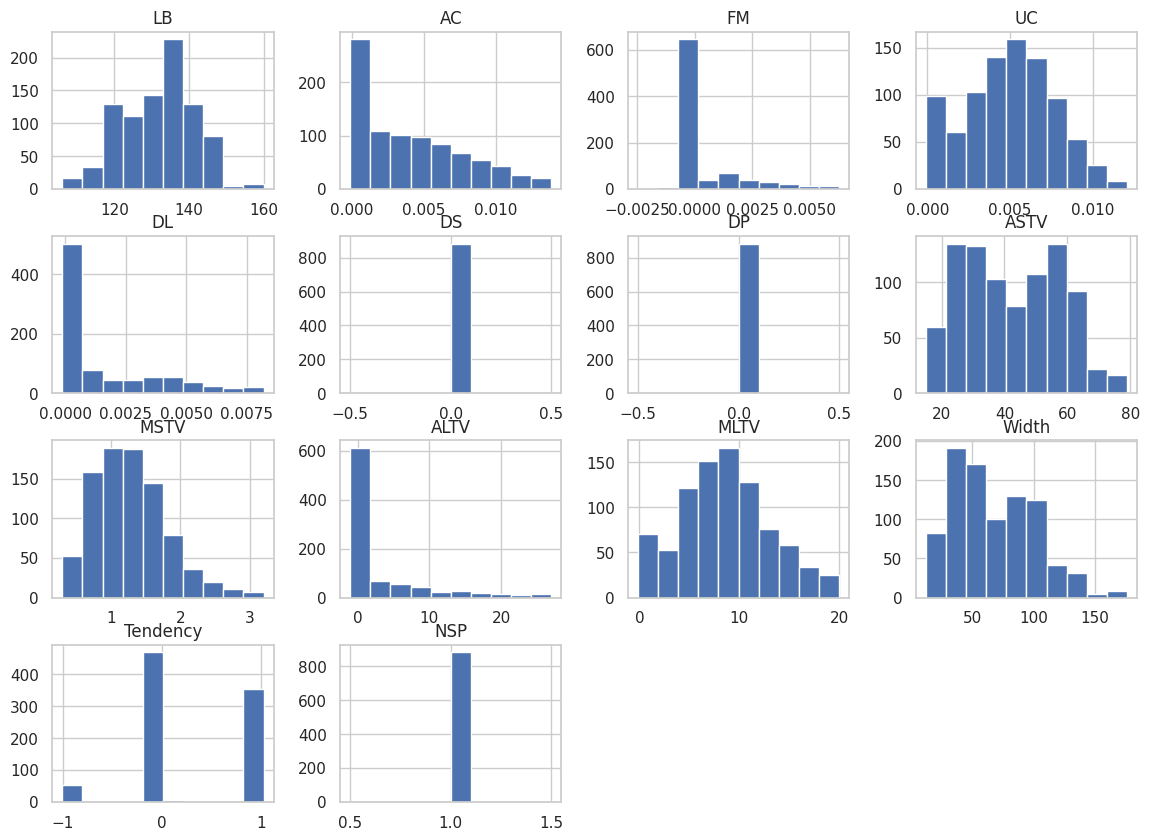

In [12]:
df_clean.hist(figsize=(14,10))
plt.show()

Histograms were used to visualize the distribution of numerical variables.

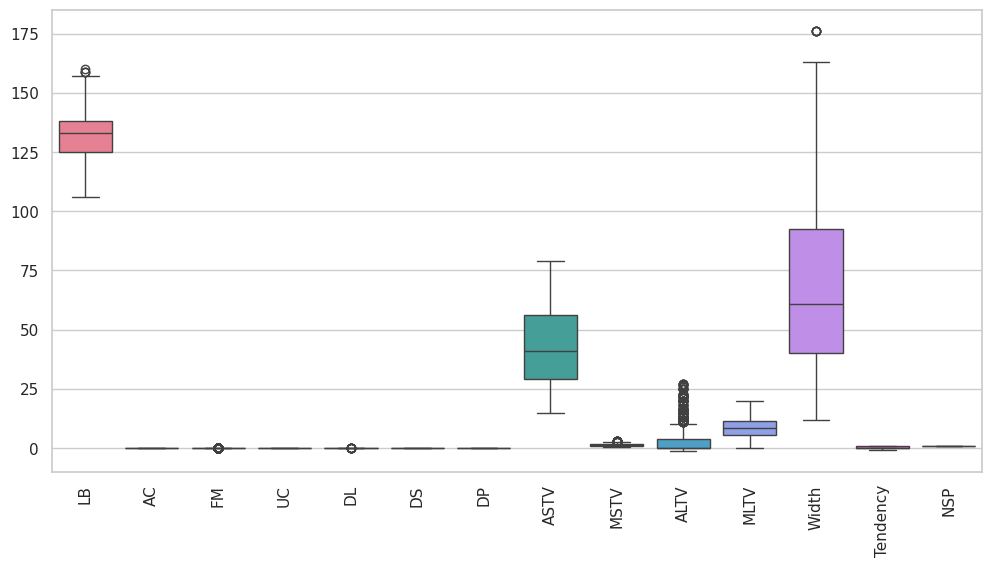

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.xticks(rotation=90)
plt.show()

Boxplots were used to verify the presence of outliers and visualize the spread of variables.

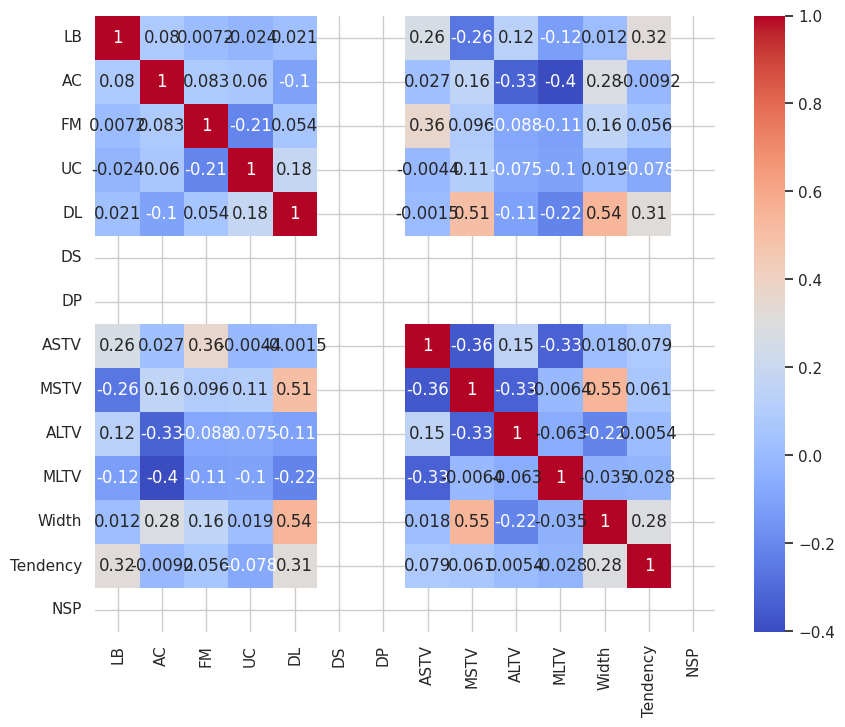

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.show()

The heatmap shows relationships between cardiographic variables and helps identify correlations.

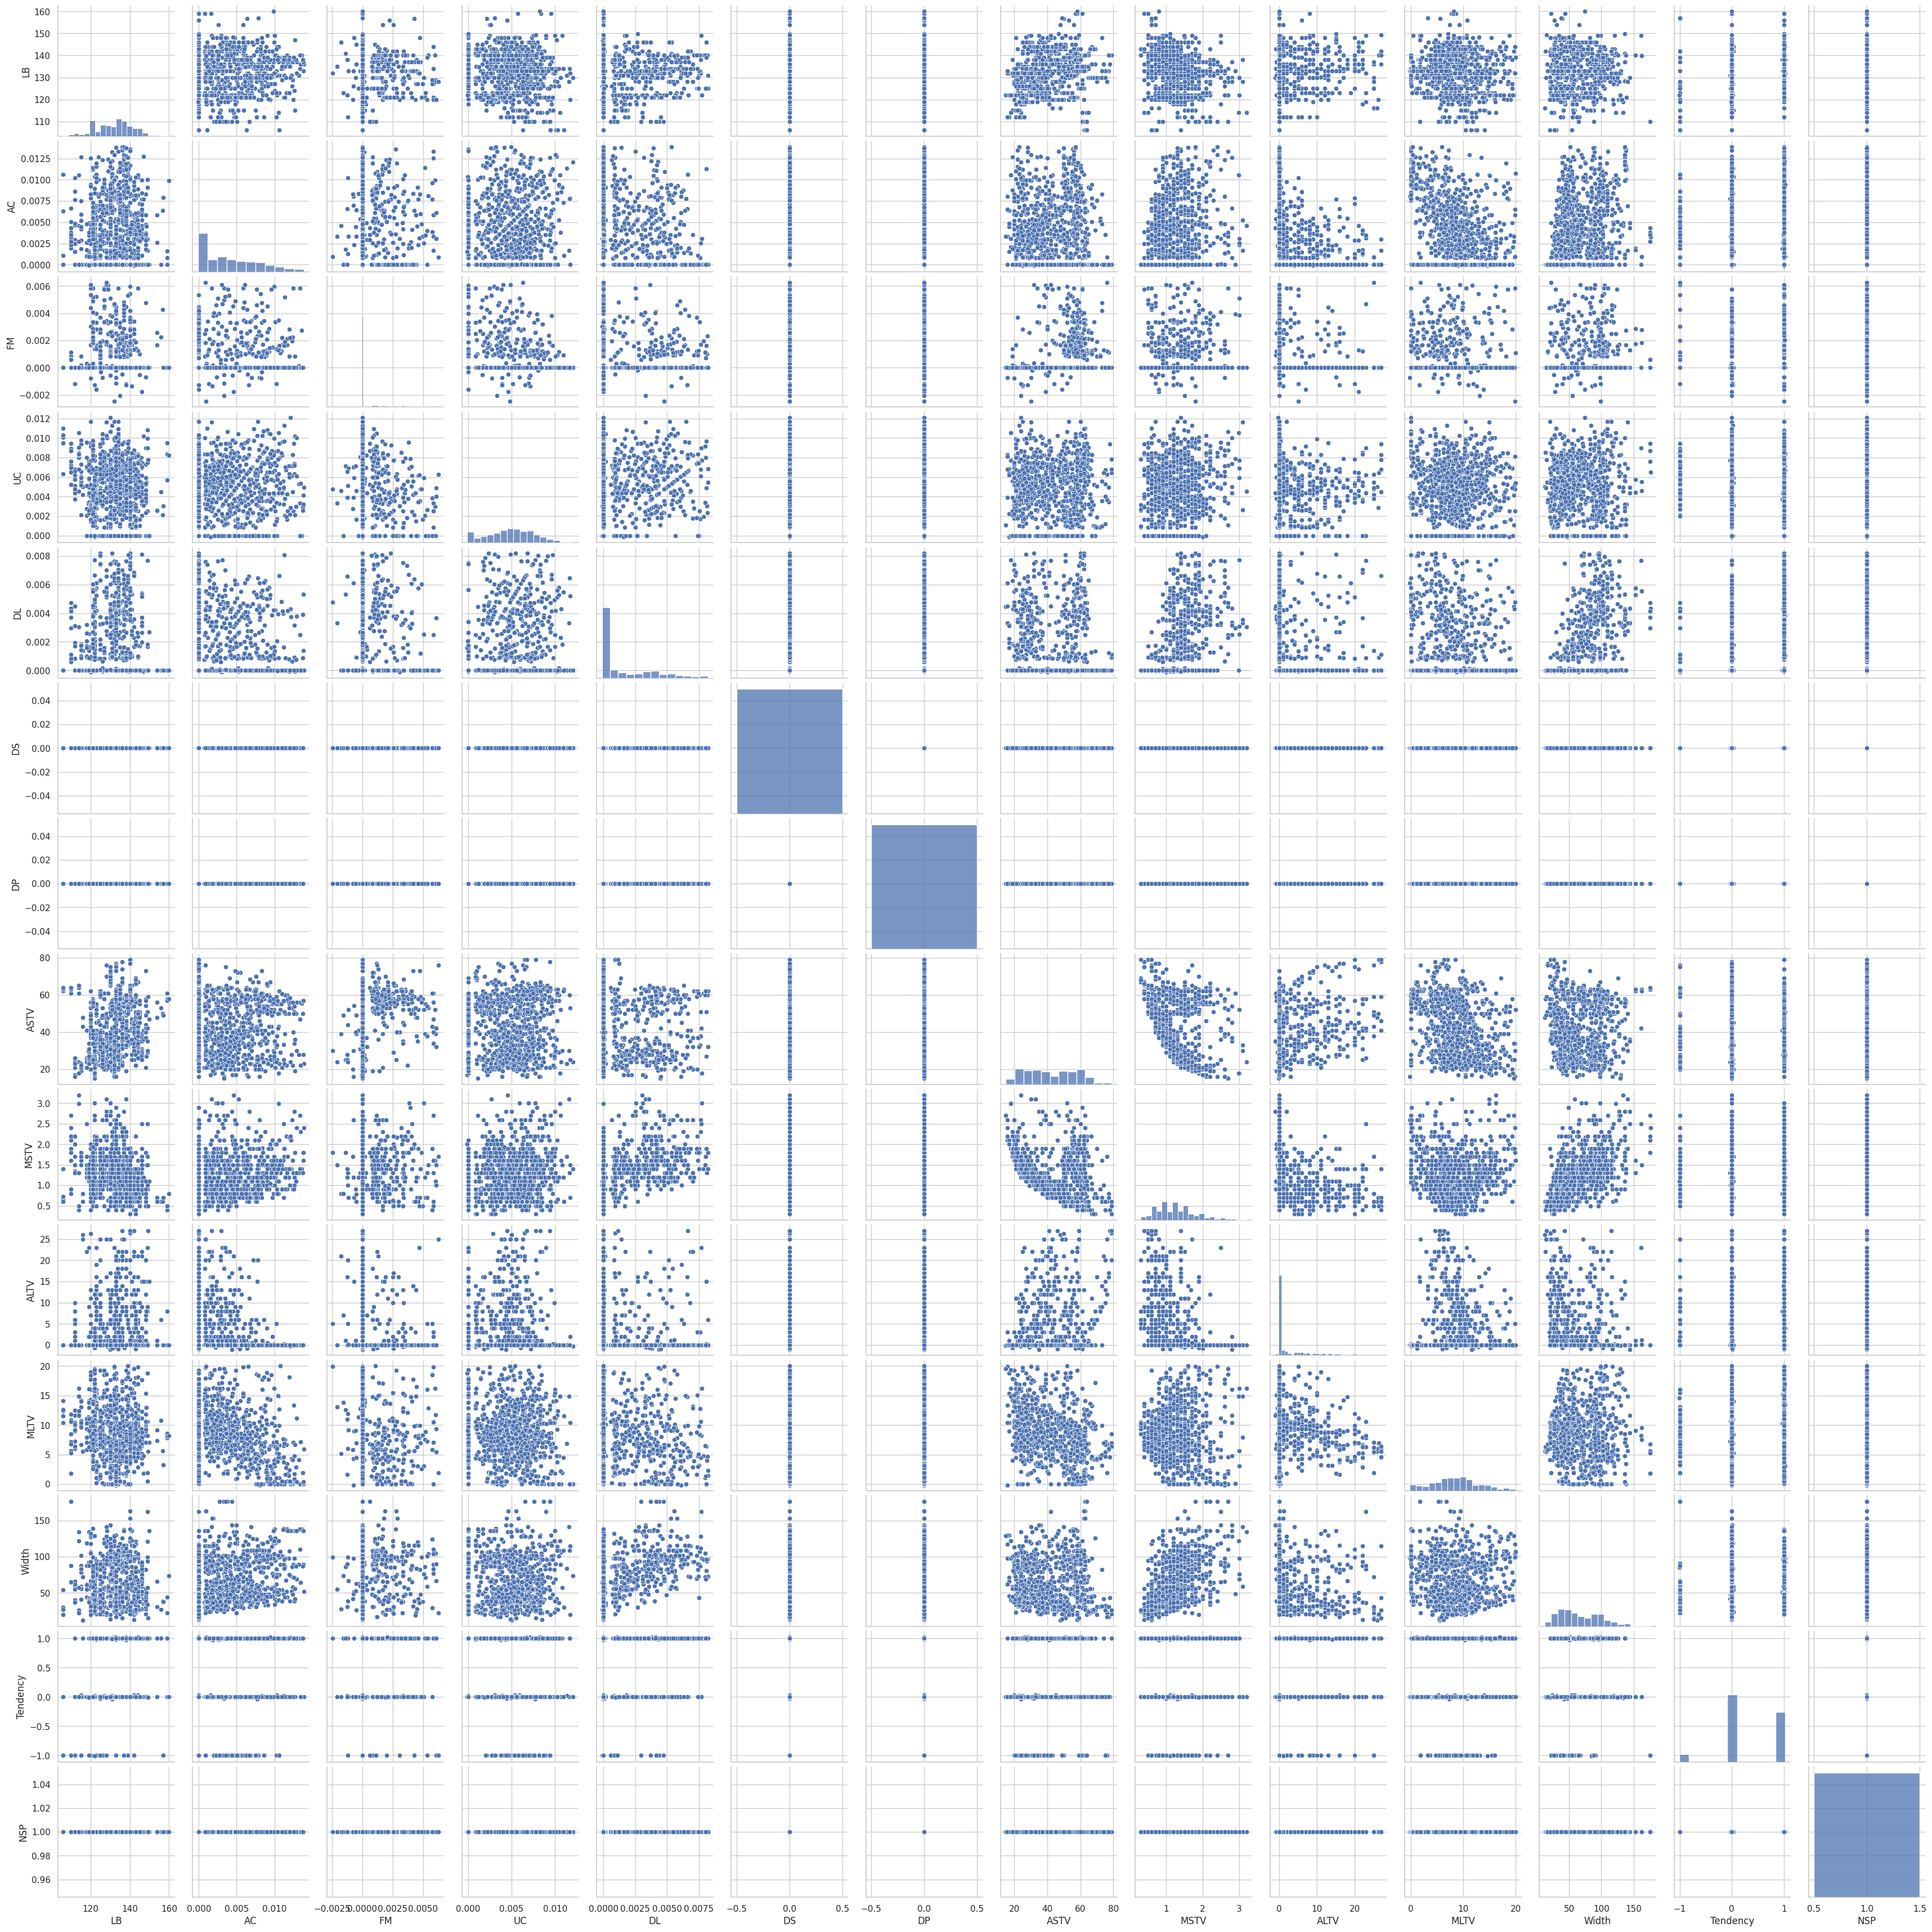

In [15]:
sns.pairplot(df_clean)
plt.show()

Pairplots were used to visualize relationships between multiple variables simultaneously.

Key Insights

• Accelerations (AC) appear positively associated with fetal well-being.
• Fetal Movements (FM) may relate to increased heart rate activity.
• Decelerations such as DL and DP may indicate potential fetal distress.
• Variability measures (ASTV, MSTV, ALTV, MLTV) are important indicators of fetal heart rate behavior.

These patterns help understand fetal health monitoring indicators.

Conclusion

The exploratory data analysis of the cardiographic dataset helped identify relationships between fetal heart rate indicators. Data cleaning and outlier treatment improved the reliability of the analysis.

Accelerations and fetal movements appear to be positive indicators of fetal health, whereas prolonged or late decelerations may signal potential distress.

Further analysis using machine learning models can be performed to classify fetal health conditions.